### Imports

In [2]:
import os
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import hashlib

### Chemin vers les datas

In [3]:
root_dir = Path("../mri_dataset_brain_cancer_oc")

### Inventaire et structure du dataset
Cette cellule parcourt l'arborescence des fichiers pour créer un DataFrame recensant le chemin, le statut et le label de chaque image. Elle permet de quantifier précisément la répartition entre les données annotées et non-annotées.

status
Unlabeled    1406
Labeled       100
Name: count, dtype: int64


C:\Users\ethan\AppData\Local\Temp\ipykernel_34588\3504667638.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='status', palette='viridis')
C:\Users\ethan\AppData\Local\Temp\ipykernel_34588\3504667638.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['status']=='Labeled'], x='label', palette='magma')


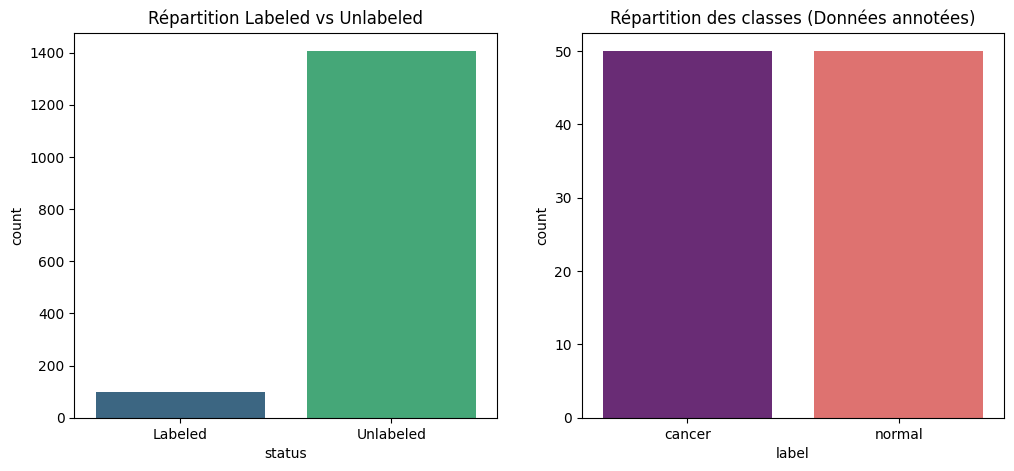

label
cancer    50
normal    50
Name: count, dtype: int64


In [4]:
def build_inventory(base_path):
    data = []
    for path in base_path.rglob('*.jpg'): # On cherche tous les PNG récursivement
        # On détermine le statut et le label
        parts = path.parts
        status = "Labeled" if "avec_labels" in parts else "Unlabeled"
        label = parts[-2] if status == "Labeled" else "Unknown"
        
        data.append({
            "path": str(path),
            "status": status,
            "label": label
        })
    return pd.DataFrame(data)

df = build_inventory(root_dir)
print(df["status"].value_counts())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='status', palette='viridis')
plt.title('Répartition Labeled vs Unlabeled')

plt.subplot(1, 2, 2)
sns.countplot(data=df[df['status']=='Labeled'], x='label', palette='magma')
plt.title('Répartition des classes (Données annotées)')
plt.show()
print(df[df["status"]=="Labeled"]["label"].value_counts())

### Vérification de l'homogénéité des dimensions
Cette étape analyse la résolution  de chaque fichier image pour s'assurer de la cohérence technique du dataset.

In [5]:
def check_dimensions(path):
    with Image.open(path) as img:
        return img.size # Retourne (largeur, hauteur)

# On crée une colonne temporaire pour les tailles
df['dimensions'] = df['path'].apply(check_dimensions)

# On regarde combien de tailles différentes on a
print("Répartition des dimensions :")
print(df['dimensions'].value_counts())

Répartition des dimensions :
dimensions
(512, 512)    1506
Name: count, dtype: int64


Pour le moment : même format pour toutes les photos, même extension, 50 labélisés dans les 2 catégories

### Visualisation qualitative des échantillons
Cette fonction affiche une grille d'images aléatoires pour comparer visuellement les classes "normal" et "cancer". Elle permet d'identifier d'éventuels biais visuels comme les différences d'angles de vue ou d'intensité lumineuse.

In [6]:
def plot_categories(df, n_samples=8):
    # On récupère les deux classes labellisées
    classes = ['normal', 'cancer']
    
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 12))
    
    for i, cls in enumerate(classes):
        # On sélectionne n images aléatoires pour chaque classe
        subset = df[df['label'] == cls].sample(n_samples)
        
        for j, (_, row) in enumerate(subset.iterrows()):
            img = Image.open(row['path'])
            ax = axes[i, j]
            ax.imshow(img, cmap='gray') # IRM en niveaux de gris
            ax.set_title(f"Classe: {cls}")
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()


### Lancement

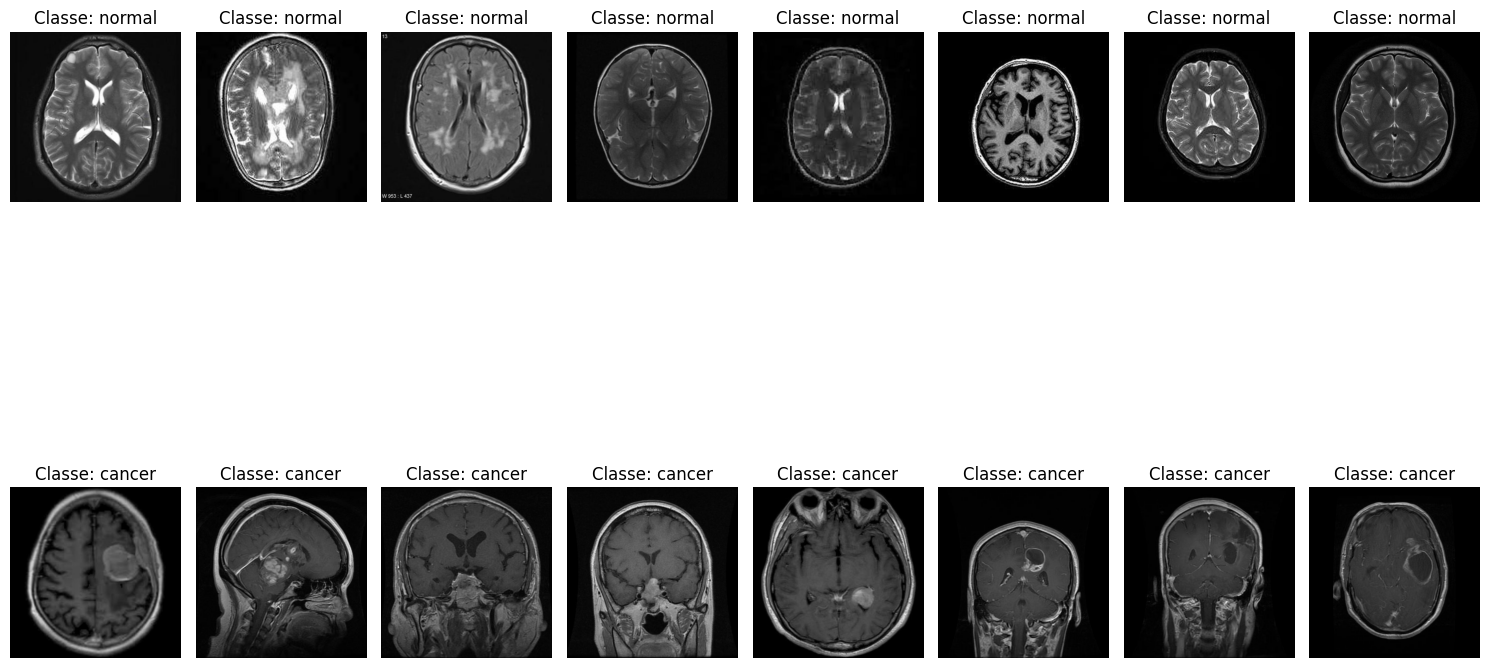

In [7]:

# On lance l'affichage
plot_categories(df)

Observation : le label "normal" contient que 1 seul type de coupe, les labels "cancers" eux comportent différentes coupes tout comme les non labélisés.

In [8]:
def check_mode(path):
    with Image.open(path) as img:
        return img.mode

# Identification du mode (L, RGB, RGBA, etc.)
df['mode'] = df['path'].apply(check_mode)

print("Répartition des modes de couleur :")
print(df['mode'].value_counts())

Répartition des modes de couleur :
mode
RGB    1506
Name: count, dtype: int64


### Analyse quantitative de l'intensité des pixels
Cette étape calcule la luminosité moyenne et le contraste (écart-type) pour chaque image du dataset.

In [9]:
def get_pixel_stats(path):
    with Image.open(path) as img:
        img_array = np.array(img)
        return img_array.mean(), img_array.std()

# On calcule la moyenne et l'écart-type pour chaque image
df[['mean_gray', 'std_gray']] = df['path'].apply(get_pixel_stats).apply(pd.Series)

### Lancement graphique

C:\Users\ethan\AppData\Local\Temp\ipykernel_34588\3620037419.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='label', y='mean_gray', data=df, palette='viridis')
C:\Users\ethan\AppData\Local\Temp\ipykernel_34588\3620037419.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='label', y='std_gray', data=df, palette='magma')


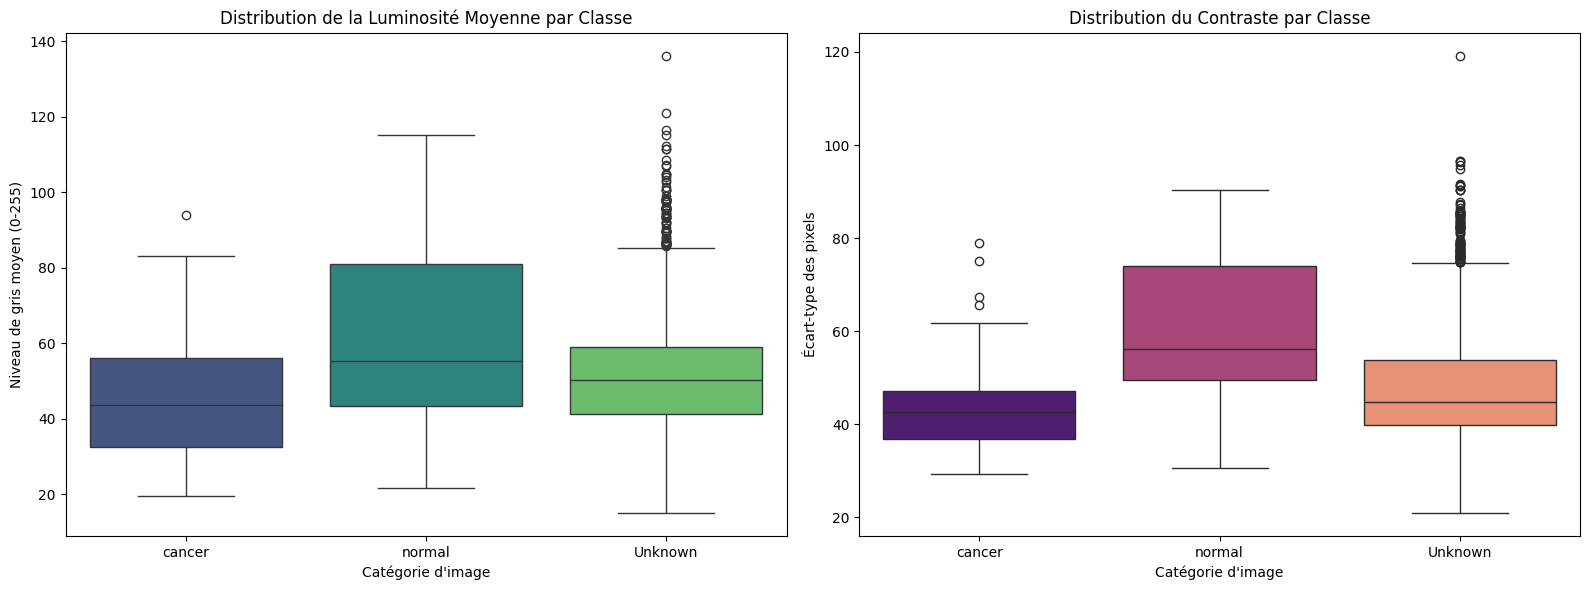

In [10]:
# On prépare la figure avec deux graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Graphique de la Luminosité Moyenne
sns.boxplot(ax=axes[0], x='label', y='mean_gray', data=df, palette='viridis')
axes[0].set_title('Distribution de la Luminosité Moyenne par Classe')
axes[0].set_ylabel('Niveau de gris moyen (0-255)')
axes[0].set_xlabel('Catégorie d\'image')

# 2. Graphique du Contraste (Écart-type)
sns.boxplot(ax=axes[1], x='label', y='std_gray', data=df, palette='magma')
axes[1].set_title('Distribution du Contraste par Classe')
axes[1].set_ylabel('Écart-type des pixels')
axes[1].set_xlabel('Catégorie d\'image')

plt.tight_layout()
plt.show()

Conclusion : les images labélisées "cancer" ont une luminosité plus faible et un contraste plus faible que les labélisées "normales". 

### Détection des doublons par hachage numérique
Cette étape calcule l'empreinte numérique (MD5) de chaque fichier pour identifier d'éventuels doublons de contenu binaire. Elle garantit l'intégrité du dataset et prévient tout risque de "data leakage" lors des phases d'apprentissage.

In [11]:
def get_image_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# Calcul du hash pour chaque fichier
df['hash'] = df['path'].apply(get_image_hash)

# Identification des doublons (on garde la première occurrence)
duplicates_count = df.duplicated('hash').sum()
print(f"Nombre de doublons exacts détectés : {duplicates_count}")

if duplicates_count > 0:
    # Visualisation de quelques doublons pour vérification
    print(df[df.duplicated('hash', keep=False)].sort_values('hash')[['path', 'label']].head(6))

Nombre de doublons exacts détectés : 96
                                                   path    label
651   ..\mri_dataset_brain_cancer_oc\sans_label\63f7...  Unknown
988   ..\mri_dataset_brain_cancer_oc\sans_label\a74c...  Unknown
1086  ..\mri_dataset_brain_cancer_oc\sans_label\b65c...  Unknown
97    ..\mri_dataset_brain_cancer_oc\avec_labels\nor...   normal
369   ..\mri_dataset_brain_cancer_oc\sans_label\2f0c...  Unknown
84    ..\mri_dataset_brain_cancer_oc\avec_labels\nor...   normal


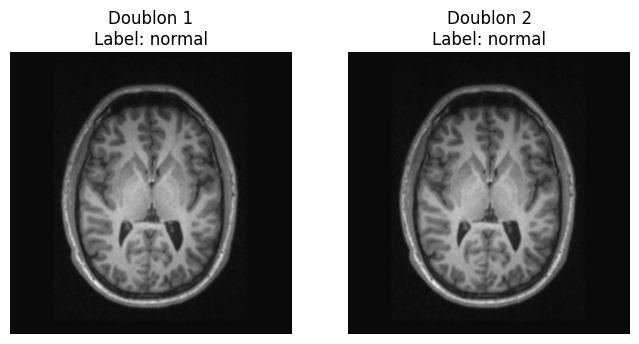

In [12]:
if duplicates_count > 0:
    # On prend le premier qui a un doublon pour l'exemple
    dup_hash = df[df.duplicated('hash')]['hash'].iloc[0]
    pair = df[df['hash'] == dup_hash].head(2)
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for i, (_, row) in enumerate(pair.iterrows()):
        axes[i].imshow(Image.open(row['path']), cmap='gray')
        axes[i].set_title(f"Doublon {i+1}\nLabel: {row['label']}")
        axes[i].axis('off')
    plt.show()

In [13]:
df_dups = df[df.duplicated('hash', keep=False)].copy()

if not df_dups.empty:
    df_dups['occurrence'] = df_dups.groupby('hash').cumcount() + 1
    
    tableau_doublons = df_dups.pivot(index='hash', columns='occurrence', values=['path', 'label'])
    tableau_doublons.columns = [f"{col[0]}_{col[1]}" for col in tableau_doublons.columns]
    tableau_doublons = tableau_doublons.reset_index()
    
    def diagnostic(row):
        labels = [row[col] for col in tableau_doublons.columns if col.startswith('label_') and pd.notna(row[col])]
        return "même label" if len(set(labels)) == 1 else "labels différents"
    
    tableau_doublons['diagnostic'] = tableau_doublons.apply(diagnostic, axis=1)
    
    # Affichage filtré : on ne garde que les lignes où le diagnostic est "labels différents"
    display(tableau_doublons[tableau_doublons['diagnostic'] == "labels différents"])
else:
    print("Aucun doublon à afficher.")

,hash,path_1,path_2,path_3,label_1,label_2,label_3,diagnostic
1,0652cb55477c4edeea5c5dfd53944e3b,..\mri_dataset_brain_cancer_oc\avec_labels\nor...,..\mri_dataset_brain_cancer_oc\sans_label\b65c...,NaN,normal,Unknown,NaN,labels différents
2,0816537db58c1d8092808f2c6f75e96c,..\mri_dataset_brain_cancer_oc\avec_labels\nor...,..\mri_dataset_brain_cancer_oc\sans_label\2f0c...,NaN,normal,Unknown,NaN,labels différents
5,1868801e49e6cd18fb2e4189250921e4,..\mri_dataset_brain_cancer_oc\avec_labels\nor...,..\mri_dataset_brain_cancer_oc\sans_label\cd33...,NaN,normal,Unknown,NaN,labels différents
6,1e2fd8da45a9cc434c617ae227ac9e27,..\mri_dataset_brain_cancer_oc\avec_labels\nor...,..\mri_dataset_brain_cancer_oc\avec_labels\nor...,..\mri_dataset_brain_cancer_oc\sans_label\1859...,normal,normal,Unknown,labels différents
7,234bef5f52771afb417f07b260c261f9,..\mri_dataset_brain_cancer_oc\avec_labels\nor...,..\mri_dataset_brain_cancer_oc\sans_label\6a70...,NaN,normal,Unknown,NaN,labels différents
15,332baa8d1fb21c1ceec02e65ad46e3e3,..\mri_dataset_brain_cancer_oc\avec_labels\nor...,..\mri_dataset_brain_cancer_oc\sans_label\af33...,NaN,normal,Unknown,NaN,labels différents
16,340cba7718cd50b43deaafa5935109dc,..\mri_dataset_brain_cancer_oc\avec_labels\nor...,..\mri_dataset_brain_cancer_oc\sans_label\8d77...,NaN,normal,Unknown,NaN,labels différents
17,34153b917f7b0535b60b20ae02adcbf8,..\mri_dataset_brain_cancer_oc\avec_labels\nor...,..\mri_dataset_brain_cancer_oc\sans_label\04dd...,NaN,normal,Unknown,NaN,labels différents
19,39b7e8e4b4ad8f609c0b5509b7945f22,..\mri_dataset_brain_cancer_oc\avec_labels\can...,..\mri_dataset_brain_cancer_oc\sans_label\cf0c...,NaN,cancer,Unknown,NaN,labels différents
23,427d44a774938b994e209142d4f31291,..\mri_dataset_brain_cancer_oc\avec_labels\nor...,..\mri_dataset_brain_cancer_oc\sans_label\d77c...,NaN,normal,Unknown,NaN,labels différents


On trouve de nombreux doublons. 
Dans le cas de même label : on garde une seule des 2 
Dans le cas de labos différents : ...

In [14]:
# On s'assure d'abord d'avoir les 'Labeled' en priorité si jamais il y a un mix
#df = df.sort_values(by=['hash', 'status'], ascending=[True, True])

# Suppression de TOUS les doublons de hash
# keep='first' ne garde que la toute première ligne rencontrée pour chaque empreinte numérique
#df_unique = df.drop_duplicates(subset='hash', keep='first').copy()

#print(f"Nettoyage des doublons identiques terminé.")
#print(f"Nombre d'images uniques conservées : {len(df_unique)}")
#print(f"Nombre de copies supprimées : {len(df) - len(df_unique)}")

#df = df_unique

### Identification des images uniformes ou corrompues
Cette étape détecte les fichiers dont le contenu est quasi-uniforme (images vides ou saturées) via un seuil sur l'écart-type des pixels. Elle permet de purifier le dataset en isolant les données techniquement inexploitables avant l'entraînement.

In [15]:
# Seuil arbitraire pour détecter une image quasi-uniforme (à ajuster selon vos observations)
low_variance_threshold = 1.0 

empty_images = df[df['std_gray'] < low_variance_threshold]
print(f"Nombre d'images potentiellement vides ou uniformes : {len(empty_images)}")

if not empty_images.empty:
    print("Chemins des images à inspecter :")
    print(empty_images['path'].tolist())

Nombre d'images potentiellement vides ou uniformes : 0


### Analyse de l'occupation spatiale (Foreground Ratio)
Cette étape calcule la proportion de pixels utiles par rapport au fond noir pour évaluer le cadrage des IRM. Elle permet de vérifier si le cerveau occupe une surface constante entre les différentes séries d'images.

In [16]:
def get_foreground_ratio(path, threshold=10):
    with Image.open(path) as img:
        img_array = np.array(img)
        # Ratio de pixels qui ne sont pas considérés comme du fond noir
        return (img_array > threshold).mean()

df['foreground_ratio'] = df['path'].apply(get_foreground_ratio)

print("Statistiques sur le ratio d'occupation du cerveau :")
print(df.groupby('label')['foreground_ratio'].describe())

Statistiques sur le ratio d'occupation du cerveau :
          count      mean       std       min       25%       50%       75%  \
label                                                                         
Unknown  1406.0  0.630775  0.133177  0.243862  0.557123  0.632995  0.705914   
cancer     50.0  0.586660  0.131498  0.316822  0.484578  0.601149  0.701655   
normal     50.0  0.660790  0.201405  0.259220  0.493139  0.627005  0.812851   

              max  
label              
Unknown  1.000000  
cancer   0.846981  
normal   0.999893  


In [17]:
if not empty_images.empty:
    plt.figure(figsize=(15, 3))
    for i in range(min(5, len(empty_images))):
        plt.subplot(1, 5, i+1)
        plt.imshow(Image.open(empty_images.iloc[i]['path']), cmap='gray')
        plt.title(f"Std: {empty_images.iloc[i]['std_gray']:.2f}")
        plt.axis('off')
    plt.show()

In [18]:
def get_content_aspect_ratio(path, threshold=10):
    with Image.open(path) as img:
        
        # C'est ce qui évite l'erreur "too many values to unpack"
        img_gray = img.convert('L') 
        img_array = np.array(img_gray)
        
        # Binarisation
        coords = np.argwhere(img_array > threshold)

        if coords.shape[0] == 0:
            return None 

        # Maintenant coords.min(axis=0) renvoie bien exactement [y, x]
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        content_width = x_max - x_min
        content_height = y_max - y_min

        if content_height == 0:
            return 0 

        return content_width / content_height

# Relance l'application
df['content_aspect_ratio'] = df['path'].apply(get_content_aspect_ratio)

In [19]:
# Afficher les statistiques pour vérifier que les chiffres ont du sens
print("Statistiques du ratio d'aspect (Largeur / Hauteur) :")
print(df['content_aspect_ratio'].describe())

# Afficher les 5 premières lignes pour voir la nouvelle colonne
df[['path', 'label', 'content_aspect_ratio']].head()

Statistiques du ratio d'aspect (Largeur / Hauteur) :
count    1506.000000
mean        0.923814
std         0.109750
min         0.466942
25%         0.851155
50%         0.933464
75%         1.000000
max         1.389646
Name: content_aspect_ratio, dtype: float64


,path,label,content_aspect_ratio
0,..\mri_dataset_brain_cancer_oc\avec_labels\can...,cancer,1.098925
1,..\mri_dataset_brain_cancer_oc\avec_labels\can...,cancer,0.852459
2,..\mri_dataset_brain_cancer_oc\avec_labels\can...,cancer,0.961140
3,..\mri_dataset_brain_cancer_oc\avec_labels\can...,cancer,0.904110
4,..\mri_dataset_brain_cancer_oc\avec_labels\can...,cancer,0.839323


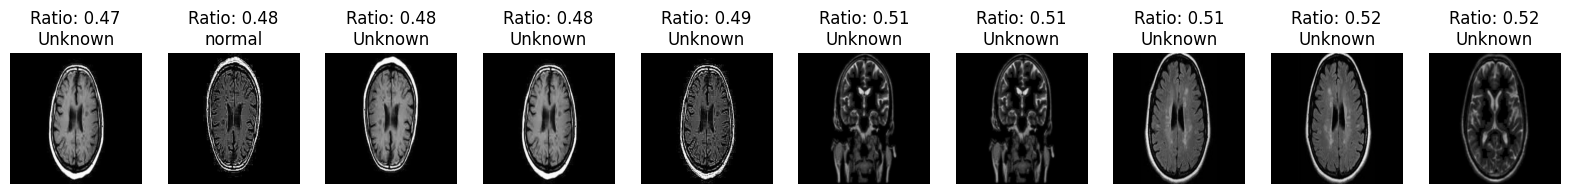

In [20]:
# On récupère les 5 images avec le plus petit ratio
worst_ratios = df.sort_values('content_aspect_ratio').head(10)

plt.figure(figsize=(20, 5))
for i, (_, row) in enumerate(worst_ratios.iterrows()):
    plt.subplot(2, 10, i+1)
    img = Image.open(row['path'])
    plt.imshow(img, cmap='gray')
    plt.title(f"Ratio: {row['content_aspect_ratio']:.2f}\n{row['label']}")
    plt.axis('off')
plt.show()

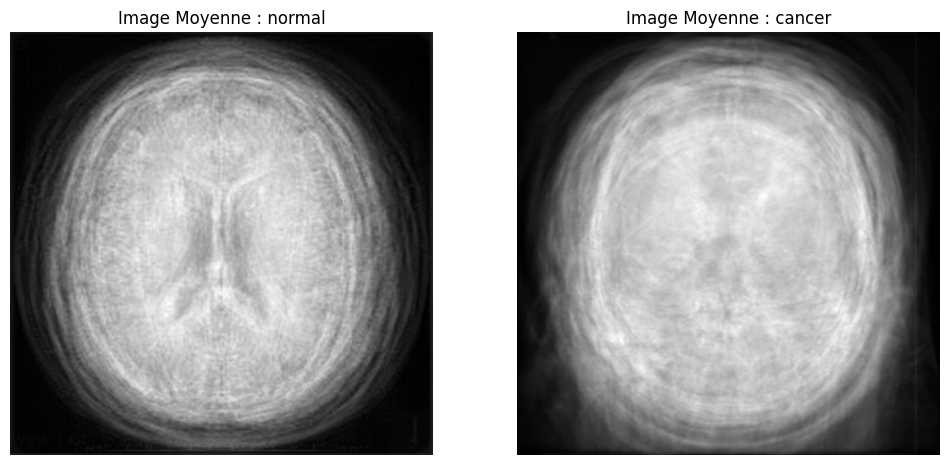

In [21]:
### Visualisation de l'image moyenne par classe
def plot_average_image(df):
    classes = ['normal', 'cancer']
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for i, cls in enumerate(classes):
        subset_paths = df[df['label'] == cls]['path'].tolist()
        # On initialise une matrice vide
        avg_img = np.zeros((512, 512), dtype=np.float32)
        
        for p in subset_paths:
            img = np.array(Image.open(p).convert('L').resize((512, 512)))
            avg_img += img
        
        avg_img /= len(subset_paths)
        
        axes[i].imshow(avg_img, cmap='gray')
        axes[i].set_title(f"Image Moyenne : {cls}")
        axes[i].axis('off')

    plt.show()

# Lancement
plot_average_image(df)